In [1]:

im_path = "../../../Images/64/"

using Lux, LuxCUDA, MLUtils, NNlib
using Optimisers, Random, Statistics
using Zygote
#using DiffEqFlux, OrdinaryDiffEq
using FFTW
using Images, JLD2
using ComponentArrays
using Plots
using Dates

In [2]:
using LinearAlgebra
using Random

# Hyperparameters for Variance Preserving (VP) SDE
const βmin = 0.1
const βmax = 20.0
T = 1
include("helperfuncs.jl")

ᾱ (generic function with 1 method)

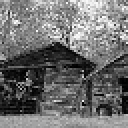

In [3]:
img = load(im_path*"7001.jpg")

β: 20.0   ᾱ: 4.318574906034135e-5


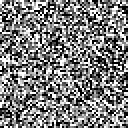

In [4]:
t=1
x0 = normalize_image(img)
xt, ϵ = forward_sample(x0,t,ᾱ)
beta_t = β(t); abar = ᾱ(t)
println("β: $beta_t   ᾱ: $abar")
img_noisy = Gray.(clamp.(denormalize_image(xt), 0.0,1.0))

Goal: get a model to predict ϵ from 

In [5]:
model= Chain(
    Conv((17, 17), 2 => 256; pad = 8),
    SkipConnection(
        Chain(
            Conv((1, 1), 256 => 512, gelu),
            SkipConnection(
                Chain(
                    Conv((1, 1), 512 => 512, gelu),
                    Conv((1, 1), 512 => 512, gelu),
                    Conv((1, 1), 512 => 512, gelu),
                ),
                +
            ),
            Conv((1, 1), 512 => 256, gelu),
            Conv((1, 1), 256 => 256, gelu),
        ),
        +
    ),
    Conv((1, 1), 256 => 128, gelu),
    Conv((1, 1), 128 => 64, gelu),
    Conv((1, 1), 64 => 1)
)

Chain(
    layer_1 = Conv((17, 17), 2 => 256, pad=8),    # 148_224 parameters
    layer_2 = SkipConnection(
        connection = +,
        layers = Chain(
            layer_1 = Conv((1, 1), 256 => 512, gelu_tanh),  # 131_584 parameters
            layer_2 = SkipConnection(
                connection = +,
                layers = Chain(
                    layer_(1-3) = Conv((1, 1), 512 => 512, gelu_tanh),  # 787_968 (262_656 x 3) parameters
                ),
            ),
            layer_3 = Conv((1, 1), 512 => 256, gelu_tanh),  # 131_328 parameters
            layer_4 = Conv((1, 1), 256 => 256, gelu_tanh),  # 65_792 parameters
        ),
    ),
    layer_3 = Conv((1, 1), 256 => 128, gelu_tanh),  # 32_896 parameters
    layer_4 = Conv((1, 1), 128 => 64, gelu_tanh),  # 8_256 parameters
    layer_5 = Conv((1, 1), 64 => 1),              # 65 parameters
)         # Total: 1_306_113 parameters,
          #        plus 0 states.

In [6]:
const cdev = cpu_device()
const gdev = gpu_device()
dev = gdev

rng = Xoshiro()

ps, st = Lux.setup(rng, model)
ps = ps |> ComponentArray{Float32}|> dev  
#@load "ps_latestvn.jld2" ps
#@load "st_latestvn.jld2" st

ps = ps |> ComponentArray |> dev
st = st |> dev

(layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple(), layer_5 = NamedTuple())

In [7]:
opt = Optimisers.NAdam(3.3e-4)
state = Optimisers.setup(opt,ps)

Leaf(NAdam(eta=0.00033, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999)))

In [ ]:
forward(img, t) = forwardsample(normalize_image(img), t, ᾱ)

forward (generic function with 1 method)

In [9]:
# rotate spatial dims (1,2) by 90° * k
function rot90_spatial(K, k::Int)
    k = mod(k, 4)
    k == 0 && return K
    k == 1 && return reverse(permutedims(K, (2,1)), dims=1)
    k == 2 && return reverse(reverse(K, dims=1), dims=2)
    k == 3 && return reverse(permutedims(K, (2,1)), dims=2)
end

# reflection (horizontal mirror)
reflect_spatial(K) = reverse(K, dims=2)

reflect_spatial (generic function with 1 method)

In [10]:
function load_images_to_array(path, t::Number, num, forward, size)
    x = t .* ones(Float32,size,size,2,num)
    y = zeros(Float32,size,size,1,num)
    for i in 1:num
        img = Float32.(load("$path$i.jpg"))
        # equivariant training:
        if rand(Bool)
            img = reflect_spatial(img)
        end
        if rand(Bool)
            img = rot90_spatial(img,1)
        end
        if rand(Bool)
            img = rot90_spatial(img,2)
        end

        xt, ϵ = forward(img,t)
        x[:,:,1,i] = xt
        y[:,:,1,i] = ϵ
    end
    return x,y
end
function load_images_to_array(path, t::AbstractArray, num, forward, size)
    x = ones(Float32,size,size,2,num)
    y = zeros(Float32,size,size,2,num)
    for i in 1:num
        img = Float32.(load("$path$i.jpg"))
        # equivariant training:
        if rand(Bool)
            img = reflect_spatial(img)
        end
        if rand(Bool)
            img = rot90_spatial(img,1)
        end
        if rand(Bool)
            img = rot90_spatial(img,2)
        end

        xt, ϵ = forward(img,t[i])
        x[:,:,1,i] = xt
        x[:,:,2,i] .* t[i] # time gets inserted
        y[:,:,1,i] = ϵ
    end
    return x,y
end

load_images_to_array (generic function with 2 methods)

In [11]:
function load_images(batchsize, path, num, forward,size,tmax=1)
    t_array = tmax .* rand(Float32, num)
    x_img,y_img = load_images_to_array(path,t_array,num, forward, size)
    DataLoader(mapobs(gdev, (x_img, y_img)); batchsize, shuffle = true)
end

load_images (generic function with 2 methods)

In [12]:
x = randn(Float32,128,128,2,4)
x_dev = x |> dev
y, st = model(x_dev, ps, st)

(Float32[-0.14277557 0.010540244 … 0.10560818 0.06773261; -0.11493807 0.14952785 … 0.042632774 -0.066768415; … ; -0.29705656 -0.080986224 … 0.08114594 -0.0161656; -0.08229907 0.10866096 … -0.10452238 -0.061141513;;;; 0.027805973 -0.22425836 … 0.040054895 0.17283033; 0.19561748 -0.16773719 … -0.038161736 0.019695356; … ; 0.14471126 0.038963497 … -0.018382 -0.094741315; 0.057779867 0.019710204 … 0.08996421 -0.030375019;;;; 0.14133485 -0.18429008 … 0.016258428 0.14833692; 0.032413527 0.15484726 … -0.24052629 -0.014088295; … ; 0.008181561 0.21444196 … 0.27301222 0.023375522; -0.20544341 0.15309773 … -0.03663754 0.1743497;;;; -0.16663668 0.17321707 … -0.0057326267 0.04128412; -0.017897792 -0.041399542 … 0.26427817 0.11035585; … ; 0.31473708 0.084658585 … -0.031518992 -0.32350302; -0.10660265 -0.20279785 … -0.06770583 -0.0988038], (layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()), layer_3 = NamedTupl

In [18]:
y

128×128×1×4 CuArray{Float32, 4, CUDACore.DeviceMemory}:
[:, :, 1, 1] =
 -0.142776    0.0105402  -0.0991661   …   0.192801    0.105608    0.0677326
 -0.114938    0.149528    0.276608       -0.154518    0.0426328  -0.0667684
 -0.035141    0.172617    0.00773883      0.081747    0.256115   -0.198646
 -0.240937    0.306067   -0.145552       -0.0105808   0.0629809  -0.0148723
  0.373547   -0.203802    0.379381        0.0567047  -0.14366     0.10946
  0.114286   -0.0800256   0.0468182   …   0.177745    0.0543567  -0.0747955
 -0.334951   -0.334697    0.100561        0.360002    0.344145    0.267084
 -0.112897    0.252195   -0.0624074       0.0890665   0.201736   -0.511274
 -0.137183    0.367666   -0.0274478       0.618726    0.253264   -0.0569594
  0.126532   -0.139587    0.229439        0.742686    0.450927    0.0177527
  ⋮                                   ⋱   ⋮                      
  0.0497188   0.28248     0.211853       -0.0446743   0.254293   -0.127762
  0.476576   -0.172535    0.13036

In [13]:
function loss_function(model, ps, st, (x, y_true))
    y_pred, st = model(x, ps, st)
    loss_mse= MSELoss()
    mse_loss = loss_mse(y_pred, y_true)
    return mse_loss, st
end

loss_function (generic function with 1 method)

In [14]:
function inner_loop(model, ps, st, data, state)
    #train_state = Lux.Training.TrainState(model, ps, st, opt)
    #Training.single_train_step!(AutoZygote(), loss_function, (x_dev, y_dev), train_state)
    (loss, st), back = Zygote.pullback(ps -> loss_function(model, ps, st, data), ps)
    grads = back((one(loss), nothing))[1]

    state, ps = Optimisers.update(state, ps, grads)
    return ps, st, state, loss
end

inner_loop (generic function with 1 method)

In [15]:
function train!(
    model,
    ps,
    st,
    opt,
    im_path,
    forward;
    epochs = 2,
    batchsize = 64,
    num_images = 7000,
    log_every = 10,
    size = 128
)
    state = Optimisers.setup(opt, ps)
    losses = Float32[]
    for epoch in 1:epochs
    t = now(); println("Starting Training for epoch $epoch ...   $t\n")

        epoch_loss = 0.0f0
        dataloader = dataloader = load_images(batchsize, im_path, num_images, forward, size)
        num_batches = length(dataloader)

        for (i, data) in enumerate(dataloader)
            ps, st, state, loss = inner_loop(model, ps, st, data, state)
            epoch_loss += loss
            push!(losses, loss)
            #print("| $i: Loss: $loss Depth: $r ")
            print("-")
            if i % log_every == 0
                t = now()
                print(
                    " Batch $i/$num_batches | " *
                    "Loss = $(round(loss; sigdigits=4))" *
                    " Time: $t \n"
                )
            end
        end

        avg_epoch_loss = epoch_loss / num_batches
        t = now()

        @save "snapshots/ps$(avg_epoch_loss)_$t.jld2" ps
        @save "ps_latestvn.jld2" ps
        @save "snapshots/st$(avg_epoch_loss)_$t.jld2" st
        @save "st_latestvn.jld2" st
        print(
            "\n=== Epoch $epoch finished | " *
            "avg loss = $(round(avg_epoch_loss; sigdigits=5)) | "*
            " Time: $t" *
            " ===\n"
        )
    end
    return ps, st, losses
end

train! (generic function with 1 method)

In [16]:
ps, st, losses = train!(
    model,
    ps,
    st,
    opt,
    im_path,
    forward;
    size = 64,
    epochs = 2
)

Starting Training for epoch 1 ...   2026-06-03T00:39:34.003



DimensionMismatch: DimensionMismatch: loss function expects size(ŷ) = (64, 64, 1, 64) to match size(y) = (64, 64, 2, 64)